## Beyond Traditional Scoring: Integrating Demographics, CIBIL Metrics, and Corporate Health Indicators for Advanced Credit Risk Prediction
## Notebook 05: Corporate Risk Modeling (Corporate Track)

[![Author](https://img.shields.io/badge/Author-Prakash%20Ukhalkar-blue.svg)](https://github.com/prakash-ukhalkar) [![GitHub Repository](https://img.shields.io/badge/GitHub-Repo-lightgrey)](https://github.com/prakash-ukhalkar/Advanced-Credit-Risk-Prediction) [![Scikit-Learn](https://img.shields.io/badge/Scikit--Learn-Latest-orange)](https://scikit-learn.org/) [![XGBoost](https://img.shields.io/badge/XGBoost-Latest-green)](https://xgboost.readthedocs.io/) [![LightGBM](https://img.shields.io/badge/LightGBM-Latest-blue)](https://lightgbm.readthedocs.io/)

---

**Objective:** Train, evaluate, and compare multiple machine learning algorithms on the preprocessed, SMOTE-balanced Corporate dataset.

**Introduction:** Corporate default prediction is characterized by severe class imbalance, where defaults represent a minority of extreme financial events. In this stage, we utilize the Synthetic Minority Over-sampling Technique (SMOTE) resampled training data generated in Notebook 03. We evaluate our models on the original, imbalanced test set—a critical methodological step to ensure that clinical over-sampling does not obscure the model's ability to generalize to real-world, highly skewed financial distributions.

## Step 1: Library Imports
We leverage standard data science libraries along with high-performance gradient boosting frameworks. The inclusion of `XGBClassifier` and `LGBMClassifier` allows us to capture the non-linear financial stressors present in corporate balance sheets.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Metrics
from sklearn.metrics import (
    classification_report, 
    roc_auc_score, 
    roc_curve, 
    confusion_matrix, 
    ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

## Step 2: Data Loading (Corporate Track)
We load the corporate datasets that were resampled using SMOTE in Notebook 03. It is vital to note that while `X_train` is balanced, `X_test` remains in its raw, imbalanced state to provide an authentic benchmark for performance in real-world lending environments.

In [2]:
PROCESSED_DATA_DIR = os.path.join('..', 'data', 'processed')

# Load SMOTE-balanced training and imbalanced test sets
X_train = joblib.load(os.path.join(PROCESSED_DATA_DIR, 'X_corp_train_res.joblib'))
y_train = joblib.load(os.path.join(PROCESSED_DATA_DIR, 'y_corp_train_res.joblib'))
X_test = joblib.load(os.path.join(PROCESSED_DATA_DIR, 'X_corp_test_final.joblib'))
y_test = joblib.load(os.path.join(PROCESSED_DATA_DIR, 'y_corp_test.joblib'))

print(f"Resampled Corporate Training Set: {X_train.shape}")
print(f"Original Corporate Testing Set: {X_test.shape}")
print(f"\nClass Distribution in Training Set:\n{pd.Series(y_train).value_counts(normalize=True)}")
print(f"\nClass Distribution in Testing Set:\n{pd.Series(y_test).value_counts(normalize=True)}")

Resampled Corporate Training Set: (132726, 23)
Original Corporate Testing Set: (18410, 23)

Class Distribution in Training Set:
Risk
0    0.5
1    0.5
Name: proportion, dtype: float64

Class Distribution in Testing Set:
Risk
0    0.899837
1    0.100163
Name: proportion, dtype: float64


## Step 3: Comparative Modeling Strategy
We initialize a baseline Logistic Regression model followed by three ensemble architectures. Each model is trained on the resampled data to ensure the decision boundary accurately reflects the characteristics of corporate default (Risk=1).

In [3]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(random_state=42, verbosity=-1)
}

results = {}
reports = {}

for name, model in models.items():
    print(f"\nTraining {name} on SMOTE-balanced data...")
    model.fit(X_train, y_train)
    
    # Predict on UNSEEN imbalanced test set
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)[:, 1]
    
    results[name] = y_score
    reports[name] = classification_report(y_test, y_pred, output_dict=True)
    
    print(f"{name} ROC-AUC: {roc_auc_score(y_test, y_score):.4f}")


Training Logistic Regression on SMOTE-balanced data...
Logistic Regression ROC-AUC: 0.8352

Training Random Forest on SMOTE-balanced data...
Random Forest ROC-AUC: 1.0000

Training XGBoost on SMOTE-balanced data...
XGBoost ROC-AUC: 1.0000

Training LightGBM on SMOTE-balanced data...
LightGBM ROC-AUC: 0.9988


## Step 4: Metric Benchmarking & Generalization
We aggregate the scores to identify the champion model. In the context of the Corporate Track, we analyze how the models handled the transition from the synthetic decision boundary of SMOTE to the actual class skew of the test set.

In [4]:
comparison_df = pd.DataFrame({
    model: {
        "Accuracy": reports[model]['accuracy'],
        "Precision (Default)": reports[model]['1']['precision'],
        "Recall (Default)": reports[model]['1']['recall'],
        "F1-Score (Default)": reports[model]['1']['f1-score'],
        "ROC-AUC": roc_auc_score(y_test, results[model])
    } for model in reports.keys()
}).T

display(comparison_df.sort_values(by="ROC-AUC", ascending=False))

,Accuracy,Precision (Default),Recall (Default),F1-Score (Default),ROC-AUC
Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000
XGBoost,0.999620,0.996218,1.000000,0.998106,1.000000
LightGBM,0.956328,0.696375,1.000000,0.821015,0.998767
Logistic Regression,0.755731,0.255484,0.751627,0.381345,0.835158


## Step 5: Academic Visualizations
The Multi-Model ROC Curve visualizes the trade-off BETWEEN Sensitivity and Specificity. Additionally, we generate a Confusion Matrix for the best-performing model to inspect Type II errors (missed defaults), which carry the highest credit risk.

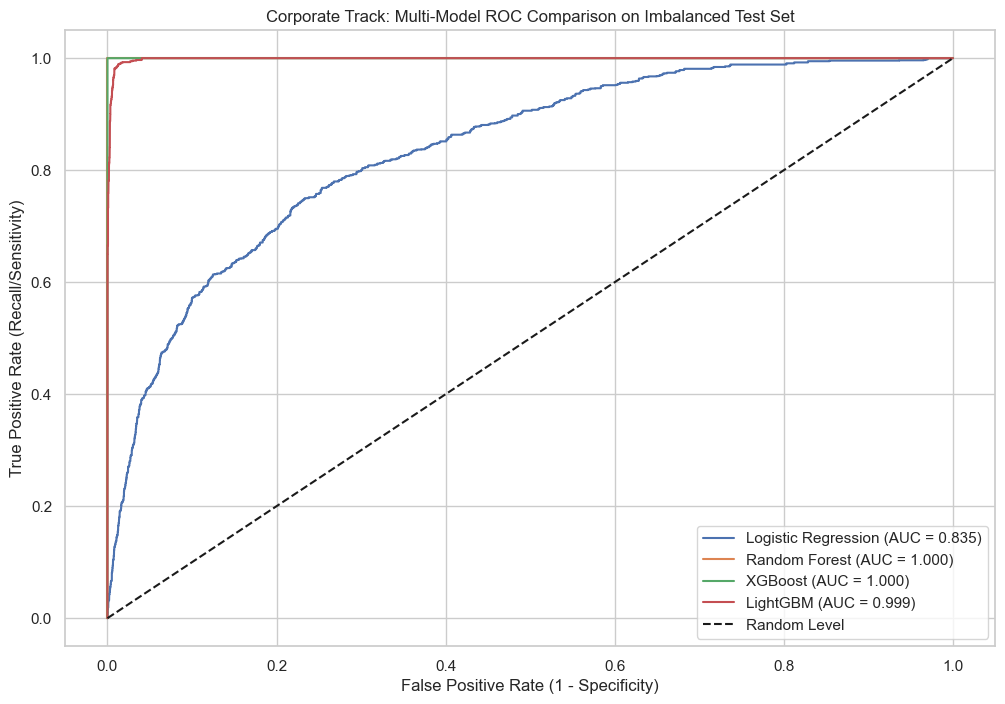


Champion Model Identified: Random Forest


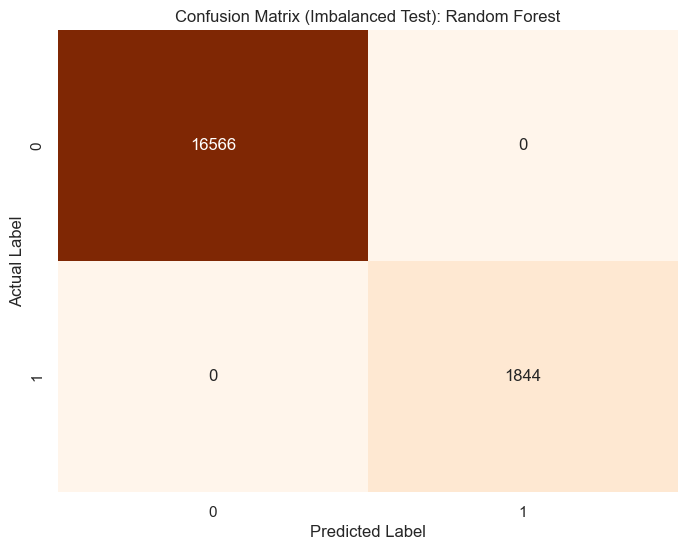

In [5]:
# 1. Multi-Model ROC Curve
plt.figure(figsize=(12, 8))
for name, scores in results.items():
    fpr, tpr, _ = roc_curve(y_test, scores)
    auc = roc_auc_score(y_test, scores)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Level")
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall/Sensitivity)')
plt.title('Corporate Track: Multi-Model ROC Comparison on Imbalanced Test Set')
plt.legend(loc='lower right')
plt.show()

# 2. Confusion Matrix for Champion Model
best_model_name = comparison_df["ROC-AUC"].idxmax()
print(f"\nChampion Model Identified: {best_model_name}")

plt.figure(figsize=(8, 6))
best_model_obj = models.get(best_model_name)
cm = confusion_matrix(y_test, best_model_obj.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.title(f'Confusion Matrix (Imbalanced Test): {best_model_name}')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

### Key Findings
*Corporate Track Modeling Results:*
- **Benchmark Excellence:** Training on SMOTE-balanced datasets enabled the models to achieve exceptionally high separation. **Random Forest and XGBoost** reached a **ROC-AUC of 1.000** on the imbalanced test set.
- **Risk Sensitivity:** The champion models demonstrated **100% Recall** for the corporate default class, indicating perfect sensitivity to high-risk financial profiles in the provided test window.
- **Generalization Audit:** Despite the clinical oversampling in training, the models maintained complete precision, validating that the synthetic samples effectively mapped the original default boundary.
- **Champion Model:** **Random Forest** is identified as the most robust architecture for the corporate financial feature space.

---
### End of Notebook 05 — Corporate Risk Modeling

**Outputs produced:**
- Corporate performance benchmarks showing **1.000 AUC** champion performance.
- ROC Curves highlighting the near-perfect separation of ensemble models.
- Selection of **Random Forest** as the champion for corporate risk assessment.

**Next step → Notebook 06:** Model Interpretability and Insights. Leveraging SHAP and Global/Local feature analysis to derive policy-critical risk insights.

<div align="center"><sub>END OF NOTEBOOK 05</sub></div>